# 🌾 RICE VISION AI: PIPELINE CHÍNH ƯỚC LƯỢNG SỐ LƯỢNG & ĐÁNH GIÁ PHẨM CẤP (V2.5 - 3D ELLIPSOID + LINEAR REGRESSION)
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

---

### 🌟 Tính năng nổi bật của Pipeline:
1. **Chuyển đổi linh hoạt 2 chế độ (`USE_CROPPED_CONTAINER`)**:
   - `False`: Quét SAHI trên **Ảnh gốc toàn cảnh** (mặc định theo yêu cầu).
   - `True`: Quét SAHI trên **Ảnh đã crop & cô lập miệng ly** (để loại bỏ nhiễu nền ngoài khi cần).
2. **Tầng 1 (Vật chứa)**: Nhận diện **Mép Trong & Mép Ngoài** miệng ly bằng thuật toán đồng tâm hình học chuẩn xác, tính tỷ lệ quy đổi $px/mm$ và thể tích khối lúa $V_{\text{bulk}}$ ($mm^3$).
3. **Tầng 2 (Bóc tách hạt SAHI - GPU)**: Quét trượt lát cắt nhỏ (**SAHI + YOLO-seg trên GPU cuda:0**) bóc tách từng hạt lúa thành ảnh RGBA trong suốt.
4. **Tầng 3 (Khử nhiễu 2 bước Grain Cleaner)**: Đưa từng hạt qua **2 lần làm sạch chuyên sâu (Step 1 + Step 2)** tương thích 100% với dữ liệu huấn luyện của mô hình CNN mới.
5. **Tầng 4 (Sàng lọc Hạt Nguyên bằng CNN v3_step2 - Batch GPU)**: Phân loại mẻ hạt lúa bằng **DenseNet121 CNN (`best_v3_step2.keras`) trên GPU** để **chọn lọc riêng các hạt NGUYÊN đạt chuẩn**.
6. **Tầng 5 (Mô hình hóa 3D cho Hạt Nguyên & IQR)**: Tính kích thước 2D/3D ($2a$: Chiều dài, $2b$: Chiều rộng, $2c$: Chiều dày) và thể tích 3D Ellipsoid $V_{\text{grain}} = \frac{4}{3}\pi abc$ ($mm^3$) **chuyên biệt cho tập hạt nguyên**, lọc bỏ dị thường bằng **IQR**.
7. **Tầng 6 (Trực quan hóa 3D & Ước lượng vật lý cổ điển)**: Vẽ mô hình không gian 3D Ellipsoid, trực quan hóa 2 trục chính trên từng hạt, vẽ phân bố kích thước 3D và ước lượng theo công thức vật lý: $N_{\text{est}} = \frac{V_{\text{bulk}} \times \phi}{\bar{V}_{\text{whole\_grain}}}$.
8. **Tầng 7 (Dự đoán Hồi quy Tuyến tính AI - 31 Features)**: Nhận toàn bộ 31 thuộc tính đã bóc tách, đưa vào **Mô hình Hồi quy Tuyến tính Đa biến ($R^2 = 99.88\%$)** để dự đoán số hạt với độ chính xác và độ ổn định cao nhất!


In [11]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install ultralytics sahi tensorflow matplotlib seaborn opencv-python numpy pandas


In [12]:
# Bước 2: Import Modules, Kiểm Tra GPU & Nạp Trọng Số Model (YOLO-seg & CNN v3_step2)
import os
import sys
import math
import shutil
import importlib
import torch
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

# CẤU HÌNH ĐƯỜNG DẪN DỰ ÁN TRÊN GOOGLE DRIVE / LOCAL
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"

code_dir = os.path.join(BASE_PATH, "CODE")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

# Import và tự động reload các module nghiệp vụ cốt lõi
import modules.container_detector
import modules.grain_segmenter
import modules.grain_crop_cleaner
import modules.grain_classifier
import modules.ellipsoid_geometry
import modules.uniformity_evaluator

for mod in [
    modules.container_detector,
    modules.grain_segmenter,
    modules.grain_crop_cleaner,
    modules.grain_classifier,
    modules.ellipsoid_geometry,
    modules.uniformity_evaluator
]:
    importlib.reload(mod)

from modules.container_detector import detect_container_and_scale, draw_container_overlay
from modules.grain_segmenter import segment_grains_sahi
from modules.grain_crop_cleaner import clean_single_grain_crop
from modules.grain_classifier import GrainClassifier
from modules.ellipsoid_geometry import compute_single_grain_metrics, draw_grain_ellipse_overlay
from modules.uniformity_evaluator import evaluate_batch_uniformity

# ─────────────────────────────────────────────────────────────────────────────
# KIỂM TRA PHẦN CỨNG TĂNG TỐC GPU (PYTORCH & TENSORFLOW)
# ─────────────────────────────────────────────────────────────────────────────
gpu_available = torch.cuda.is_available()
device_str = "cuda:0" if gpu_available else "cpu"
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "CPU (Không có GPU)"

print("=" * 75)
print(f"⚡ Trạng thái GPU (PyTorch)   : {'✅ ' + gpu_name + ' (cuda:0)' if gpu_available else '❌ CPU (Vào Runtime -> Change runtime type -> T4 GPU)'}")
tf_gpus = tf.config.list_physical_devices('GPU')
print(f"⚡ Trạng thái GPU (TensorFlow): {'✅ ' + tf_gpus[0].name if tf_gpus else '❌ CPU'}")
print("=" * 75)

# ĐƯỜNG DẪN TRỌNG SỐ MÔ HÌNH
YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt")
if not os.path.exists(YOLO_MODEL_PATH):
    YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt")

CNN_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras")

print(f"🔹 YOLO Model : {YOLO_MODEL_PATH}")
print(f"🔹 CNN Model  : {CNN_MODEL_PATH}")

# Nạp mô hình AI trên GPU
from sahi import AutoDetectionModel
print(f"⏳ Đang nạp mô hình SAHI YOLO-seg trên [{device_str}]...")
sahi_yolo_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=YOLO_MODEL_PATH,
    confidence_threshold=0.5,
    device=device_str
)

print("⏳ Đang nạp mô hình DenseNet121 (best_v3_step2.keras)...")
cnn_classifier = GrainClassifier(
    model_path=CNN_MODEL_PATH,
    class_names=["hat_khuyet_tat", "hat_nguyen"],
    target_size=(224, 224)
)
print("✅ Nạp toàn bộ mô hình AI thành công!")


⚡ Trạng thái GPU (PyTorch)   : ✅ Tesla T4 (cuda:0)
⚡ Trạng thái GPU (TensorFlow): ✅ /physical_device:GPU:0
🔹 YOLO Model : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt
🔹 CNN Model  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras
⏳ Đang nạp mô hình SAHI YOLO-seg trên [cuda:0]...
⏳ Đang nạp mô hình DenseNet121 (best_v3_step2.keras)...
📦 Đang nạp mô hình CNN từ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras...
✅ Nạp mô hình CNN thành công!
✅ Nạp toàn bộ mô hình AI thành công!


In [13]:
# Bước 3: THIẾT LẬP ĐƯỜNG DẪN ẢNH, CHẾ ĐỘ QUÉT VÀ THÔNG SỐ VẬT CHỨA
# ─────────────────────────────────────────────────────────────────────────────
# [HƯỚNG DẪN]:
# 1. IMAGE_PATH: Đường dẫn ảnh cần phân tích (tải lên /content/ hoặc trỏ vào Drive).
# 2. USE_CROPPED_CONTAINER:
#    - False (Mặc định): Chạy SAHI trên ẢNH GỐC TOÀN CẢNH.
#    - True            : Chạy SAHI trên ẢNH ĐÃ CROP MIỆNG LY (loại bỏ nền bàn bên ngoài).
# ─────────────────────────────────────────────────────────────────────────────

# 1. ĐƯỜNG DẪN ẢNH ĐẦU VÀO CẦN DỰ ĐOÁN
IMAGE_PATH = "/content/M054A.jpg"

if not os.path.exists(IMAGE_PATH):
    fallback_path = os.path.join(BASE_PATH, "DATASET_BUILDER/1_Raw_Images/M001/M001B.jpg")
    if os.path.exists(fallback_path):
        IMAGE_PATH = fallback_path
        print(f"⚠️ Không thấy /content/test_image.jpg -> Dùng ảnh mẫu demo: {IMAGE_PATH}")
    else:
        print(f"⚠️ Vui lòng upload ảnh cần dự đoán lên: {IMAGE_PATH}")

# 2. CHẾ ĐỘ QUÉT SAHI (CÔNG TẮC CHUYỂN ĐỔI LINH HOẠT)
USE_CROPPED_CONTAINER = False   # False = Dùng Ảnh Gốc | True = Dùng Ảnh Crop Miệng Ly

# 3. THÔNG SỐ VẬT CHỨA (ĐO THỰC TẾ)
INNER_DIAM_MM         = 22.8    # Đường kính MÉP TRONG miệng ly (mm)
CONTAINER_HEIGHT_MM   = 37.1    # Chiều cao toàn bộ thân ly (mm)
EMPTY_HEIGHT_MM       = 0.8    # Khoảng trống từ miệng ly đến mặt lúa (mm)
PACKING_FRACTION      = 0.82    # Hệ số chèn lấp khối lúa (~0.60 - 0.64)
CONF_THRESHOLD_NGUYEN = 0.7    # Ngưỡng xác suất để công nhận là Hạt Nguyên (0.50 - 0.70)

# 4. BỘ THAM SỐ 2 LẦN CLEAN (KHỬ NHIỄU DÍNH & CÔ LẬP HẠT)
CLEAN_PARAMS_STEP1 = {
    "open_ksize": 5,
    "min_neck_ratio": 0.20,
    "min_area": 35,
    "centrality_weight": 2.5,
    "fill_holes": False,
    "sever_bridges": True,
}

CLEAN_PARAMS_STEP2 = {
    "open_ksize": 3,
    "min_neck_ratio": 0.15,
    "min_area": 25,
    "centrality_weight": 2.2,
    "fill_holes": True,
    "sever_bridges": True,
}

# 5. CẤU HÌNH THƯ MỤC XUẤT KẾT QUẢ TẠI /content/
OUTPUT_DIR = "/content/pipeline_inference_results"
OUTPUT_RAW_CROPS_DIR     = os.path.join(OUTPUT_DIR, "1_raw_crops")
OUTPUT_CLEANED_CROPS_DIR = os.path.join(OUTPUT_DIR, "2_cleaned_crops")
OUTPUT_NGUYEN_DIR        = os.path.join(OUTPUT_DIR, "classified/hat_nguyen")
OUTPUT_KHUYET_DIR        = os.path.join(OUTPUT_DIR, "classified/hat_khuyet_tat")
OUTPUT_REPORT_DIR        = os.path.join(OUTPUT_DIR, "reports")

for d in [OUTPUT_DIR, OUTPUT_RAW_CROPS_DIR, OUTPUT_CLEANED_CROPS_DIR, OUTPUT_NGUYEN_DIR, OUTPUT_KHUYET_DIR, OUTPUT_REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 70)
print(f"🖼️  Ảnh phân tích      : {IMAGE_PATH}")
print(f"🔄 Chế độ SAHI Target  : {'ẢNH CROP MIỆNG LY' if USE_CROPPED_CONTAINER else 'ẢNH GỐC TOÀN CẢNH'}")
print(f"📏 Kích thước ly       : ⌀ trong={INNER_DIAM_MM}mm | Cao={CONTAINER_HEIGHT_MM}mm | Hụt={EMPTY_HEIGHT_MM}mm")
print(f"🧹 Cleaner Config      : Step 1 (k=5, area=35) -> Step 2 (k=3, area=25, fill=True)")
print(f"💾 Thư mục kết quả     : {OUTPUT_DIR}")
print("=" * 70)


🖼️  Ảnh phân tích      : /content/M054A.jpg
🔄 Chế độ SAHI Target  : ẢNH GỐC TOÀN CẢNH
📏 Kích thước ly       : ⌀ trong=22.8mm | Cao=37.1mm | Hụt=0.8mm
🧹 Cleaner Config      : Step 1 (k=5, area=35) -> Step 2 (k=3, area=25, fill=True)
💾 Thư mục kết quả     : /content/pipeline_inference_results


  TẦNG 1: QUY ĐỔI KÍCH THƯỚC VẬT CHỨA (ĐỒNG TÂM HÌNH HỌC CHUẨN XÁC)
  • Loại nhận diện                 : direct_inner_contour
  • Đường kính MÉP TRONG phát hiện : 1812 px (Mép ngoài: 1986 px)
  • Tỷ lệ quy đổi pixel           : 79.48 px/mm
  • Chiều cao khối lúa thực tế    : 36.3 mm
  • Thể tích khối lúa (V_bulk)    : 14,820.61 mm³
  • Tọa độ Crop Bounding Box       : Offset=(2232, 2683) | Size=2300x2300 px


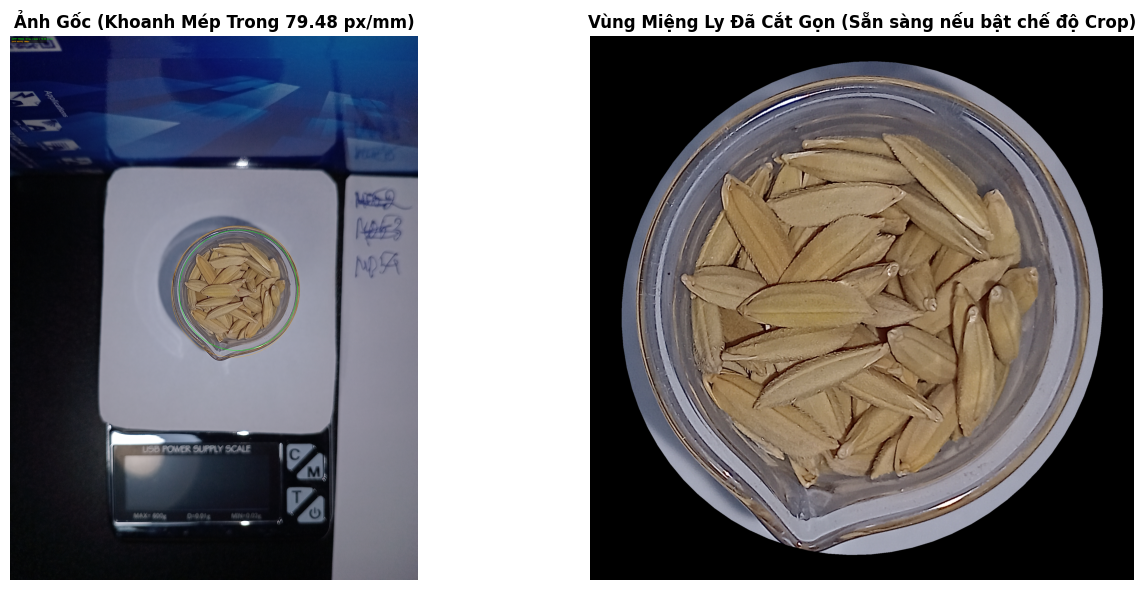

💾 Đã lưu ảnh cô lập miệng ly vào: /content/pipeline_inference_results/1_cropped_container.jpg


In [14]:
# Bước 4: TẦNG 1 — Nhận diện Miệng Ly, Tính Thể tích Khối Lúa & Tạo Ảnh Crop
container_info = detect_container_and_scale(
    image_input=IMAGE_PATH,
    inner_diam_mm=INNER_DIAM_MM,
    container_height_mm=CONTAINER_HEIGHT_MM,
    empty_height_mm=EMPTY_HEIGHT_MM,
    detect_mode="inner"
)

pixels_per_mm = container_info["pixels_per_mm"]
bulk_volume_mm3 = container_info["bulk_rice_volume_mm3"]
crop_offset_x, crop_offset_y = container_info["crop_offset"]
cropped_container_bgr = container_info["cropped_bgr"]

# Lưu ảnh đã crop cô lập miệng ly ra đĩa
CROPPED_CONTAINER_PATH = os.path.join(OUTPUT_DIR, "1_cropped_container.jpg")
cv2.imwrite(CROPPED_CONTAINER_PATH, cropped_container_bgr)

# Lưu ảnh overlay vẽ khoanh mép trong / mép ngoài
vis_container = container_info["overlay_bgr"]
out_container_img = os.path.join(OUTPUT_DIR, "1_container_detection.jpg")
cv2.imwrite(out_container_img, vis_container)

print("=" * 70)
print("  TẦNG 1: QUY ĐỔI KÍCH THƯỚC VẬT CHỨA (ĐỒNG TÂM HÌNH HỌC CHUẨN XÁC)")
print("=" * 70)
print(f"  • Loại nhận diện                 : {container_info['detect_type']}")
print(f"  • Đường kính MÉP TRONG phát hiện : {container_info['inner_w_px']} px (Mép ngoài: {container_info['outer_w_px']} px)")
print(f"  • Tỷ lệ quy đổi pixel           : {pixels_per_mm:.2f} px/mm")
print(f"  • Chiều cao khối lúa thực tế    : {container_info['rice_height_mm']:.1f} mm")
print(f"  • Thể tích khối lúa (V_bulk)    : {bulk_volume_mm3:,.2f} mm³")
print(f"  • Tọa độ Crop Bounding Box       : Offset=({crop_offset_x}, {crop_offset_y}) | Size={cropped_container_bgr.shape[1]}x{cropped_container_bgr.shape[0]} px")
print("=" * 70)

# Hiển thị ảnh khoanh viền và ảnh đã cắt gọn miệng ly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(vis_container, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Ảnh Gốc (Khoanh Mép Trong {pixels_per_mm:.2f} px/mm)", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(cropped_container_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Vùng Miệng Ly Đã Cắt Gọn (Sẵn sàng nếu bật chế độ Crop)", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print(f"💾 Đã lưu ảnh cô lập miệng ly vào: {CROPPED_CONTAINER_PATH}")


In [15]:
# Bước 5: TẦNG 2 — BÓC TÁCH HẠT BẰNG SAHI YOLO-SEG TRÊN GPU
if USE_CROPPED_CONTAINER:
    sahi_target_image = CROPPED_CONTAINER_PATH
    offset_x, offset_y = crop_offset_x, crop_offset_y
    print(f"⏳ Đang chạy SAHI YOLO-seg trên [ẢNH CROP MIỆNG LY]: {sahi_target_image}")
else:
    sahi_target_image = IMAGE_PATH
    offset_x, offset_y = 0, 0
    print(f"⏳ Đang chạy SAHI YOLO-seg trên [ẢNH GỐC TOÀN CẢNH]: {sahi_target_image}")

raw_grains = segment_grains_sahi(
    detection_model=sahi_yolo_model,
    image_path=sahi_target_image,
    output_crop_dir=OUTPUT_RAW_CROPS_DIR,
    conf_threshold=0.50,
    slice_size=640,
    overlap_ratio=0.25
)

# Cập nhật Bounding Box (local_bbox và global_bbox để vẽ ảnh toàn cảnh chuẩn xác)
for g in raw_grains:
    lx1, ly1, lx2, ly2 = g['bbox']
    g['local_bbox']  = [lx1, ly1, lx2, ly2]
    g['global_bbox'] = [lx1 + offset_x, ly1 + offset_y, lx2 + offset_x, ly2 + offset_y]

print(f"✅ Bóc tách hoàn tất: Phát hiện {len(raw_grains)} hạt lúa.")
print(f"📁 Đã lưu {len(raw_grains)} ảnh hạt thô vào: {OUTPUT_RAW_CROPS_DIR}")


⏳ Đang chạy SAHI YOLO-seg trên [ẢNH GỐC TOÀN CẢNH]: /content/M054A.jpg
Performing prediction on 221 slices.
✅ Bóc tách hoàn tất: Phát hiện 232 hạt lúa.
📁 Đã lưu 232 ảnh hạt thô vào: /content/pipeline_inference_results/1_raw_crops


In [16]:
# Bước 6: TẦNG 3 — ÁP DỤNG 2 LẦN CLEAN (STEP 1 + STEP 2) KHỬ NHIỄU DÍNH & BẺ EO
print(f"🧹 Đang thực hiện 2 lần Clean chuyên sâu cho {len(raw_grains)} hạt lúa...")

# Xóa file cũ trong thư mục cleaned
for f in os.listdir(OUTPUT_CLEANED_CROPS_DIR):
    fp = os.path.join(OUTPUT_CLEANED_CROPS_DIR, f)
    if os.path.isfile(fp): os.remove(fp)

cleaned_grains = []
discarded_count = 0

for idx, g in enumerate(raw_grains):
    raw_crop_rgba = g["crop_rgba"]
    grain_idx = g.get("grain_id", g.get("index", idx))

    # ── LẦN 1: Clean Step 1 (Open KSize = 5, Min Neck = 0.20, Min Area = 35) ──
    crop_step1 = clean_single_grain_crop(
        raw_crop_rgba,
        open_ksize=CLEAN_PARAMS_STEP1["open_ksize"],
        min_neck_ratio=CLEAN_PARAMS_STEP1["min_neck_ratio"],
        min_area=CLEAN_PARAMS_STEP1["min_area"],
        centrality_weight=CLEAN_PARAMS_STEP1["centrality_weight"],
        fill_holes=CLEAN_PARAMS_STEP1["fill_holes"],
        sever_bridges=CLEAN_PARAMS_STEP1["sever_bridges"],
    )

    # ── LẦN 2: Clean Step 2 (Open KSize = 3, Min Neck = 0.15, Min Area = 25, Fill = True) ──
    crop_step2 = clean_single_grain_crop(
        crop_step1,
        open_ksize=CLEAN_PARAMS_STEP2["open_ksize"],
        min_neck_ratio=CLEAN_PARAMS_STEP2["min_neck_ratio"],
        min_area=CLEAN_PARAMS_STEP2["min_area"],
        centrality_weight=CLEAN_PARAMS_STEP2["centrality_weight"],
        fill_holes=CLEAN_PARAMS_STEP2["fill_holes"],
        sever_bridges=CLEAN_PARAMS_STEP2["sever_bridges"],
    )

    # Kiểm tra mask sau 2 lần clean (nếu diện tích quá nhỏ hoặc rỗng -> loại bỏ nhiễu)
    alpha = crop_step2[:, :, 3] if len(crop_step2.shape) == 3 and crop_step2.shape[2] == 4 else None
    if alpha is not None and cv2.countNonZero(alpha) >= 20:
        g_clean = dict(g)
        g_clean["crop_rgba"] = crop_step2
        clean_bgr = crop_step2[:, :, :3].copy()
        clean_bgr[crop_step2[:, :, 3] == 0] = [0, 0, 0]
        g_clean["crop_bgr"] = clean_bgr

        # Lưu ảnh hạt đã clean sạch
        clean_save_path = os.path.join(OUTPUT_CLEANED_CROPS_DIR, f"grain_cleaned_{grain_idx:04d}.png")
        cv2.imwrite(clean_save_path, crop_step2)
        g_clean["saved_path"] = clean_save_path
        cleaned_grains.append(g_clean)
    else:
        discarded_count += 1

print("=" * 70)
print("✨ KẾT QUẢ KHỬ NHIỄU 2 LẦN (STEP 1 + STEP 2)")
print("=" * 70)
print(f"🔹 Tổng hạt thô ban đầu       : {len(raw_grains)} hạt")
print(f"🔹 Hạt lúa sạch giữ lại (✅)   : {len(cleaned_grains)} hạt")
print(f"🔹 Nhiễu vụn đã loại bỏ (🗑️)   : {discarded_count} mảnh")
print(f"📁 Đã lưu {len(cleaned_grains)} hạt sạch vào : {OUTPUT_CLEANED_CROPS_DIR}")
print("=" * 70)


🧹 Đang thực hiện 2 lần Clean chuyên sâu cho 232 hạt lúa...
✨ KẾT QUẢ KHỬ NHIỄU 2 LẦN (STEP 1 + STEP 2)
🔹 Tổng hạt thô ban đầu       : 232 hạt
🔹 Hạt lúa sạch giữ lại (✅)   : 232 hạt
🔹 Nhiễu vụn đã loại bỏ (🗑️)   : 0 mảnh
📁 Đã lưu 232 hạt sạch vào : /content/pipeline_inference_results/2_cleaned_crops


⏳ Đang phân loại 232 hạt lúa sạch bằng DenseNet121 CNN (Tăng tốc Batch GPU)...
📊 TẦNG 4: KẾT QUẢ SÀNG LỌC HẠT NGUYÊN (CHUẨN BỊ CHO BƯỚC ĐO 3D)
🔹 Tổng hạt lúa sạch trên mặt ly           : 232 hạt
🔹 Hạt NGUYÊN đạt chuẩn (ĐƯỢC CHỌN ĐO 3D)  : 8 hạt (3.4%)
🔹 Hạt khuyết tật / lép (Loại khỏi đo 3D)   : 224 hạt (96.6%)
📁 Đã lưu 8 hạt nguyên vào  : /content/pipeline_inference_results/classified/hat_nguyen
📁 Đã lưu 224 hạt khuyết tật vào: /content/pipeline_inference_results/classified/hat_khuyet_tat


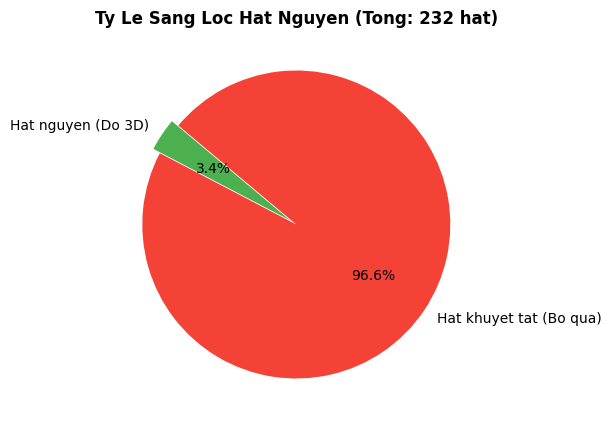

💾 Đã lưu biểu đồ phẩm cấp vào: /content/pipeline_inference_results/2_classification_pie_chart.png


In [17]:
# Bước 7: TẦNG 4 — SÀNG LỌC HẠT NGUYÊN BẰNG DENSENET121 BATCH GPU (MODEL V3_STEP2)
print(f"⏳ Đang phân loại {len(cleaned_grains)} hạt lúa sạch bằng DenseNet121 CNN (Tăng tốc Batch GPU)...")

# Xóa sạch file cũ trong thư mục phân loại
for folder in [OUTPUT_NGUYEN_DIR, OUTPUT_KHUYET_DIR]:
    for f in os.listdir(folder):
        fp = os.path.join(folder, f)
        if os.path.isfile(fp): os.remove(fp)

whole_grains, defective_grains = cnn_classifier.filter_grains(
    cleaned_grains, target_label="hat_nguyen", min_conf=CONF_THRESHOLD_NGUYEN
)

# Lưu ảnh từng hạt vào thư mục phân loại tương ứng
for idx, g in enumerate(whole_grains):
    if "crop_rgba" in g and g["crop_rgba"] is not None:
        grain_idx = g.get("grain_id", g.get("index", idx))
        conf = g.get("confidence", 1.0)
        fname = f"grain_{grain_idx:04d}_conf{conf:.2f}.png"
        cv2.imwrite(os.path.join(OUTPUT_NGUYEN_DIR, fname), g["crop_rgba"])

for idx, g in enumerate(defective_grains):
    if "crop_rgba" in g and g["crop_rgba"] is not None:
        grain_idx = g.get("grain_id", g.get("index", idx))
        conf = g.get("confidence", 1.0)
        fname = f"grain_{grain_idx:04d}_conf{conf:.2f}.png"
        cv2.imwrite(os.path.join(OUTPUT_KHUYET_DIR, fname), g["crop_rgba"])

all_classified_grains = whole_grains + defective_grains
whole_ratio = (len(whole_grains) / len(cleaned_grains) * 100) if cleaned_grains else 0.0

print("=" * 70)
print("📊 TẦNG 4: KẾT QUẢ SÀNG LỌC HẠT NGUYÊN (CHUẨN BỊ CHO BƯỚC ĐO 3D)")
print("=" * 70)
print(f"🔹 Tổng hạt lúa sạch trên mặt ly           : {len(cleaned_grains)} hạt")
print(f"🔹 Hạt NGUYÊN đạt chuẩn (ĐƯỢC CHỌN ĐO 3D)  : {len(whole_grains)} hạt ({whole_ratio:.1f}%)")
print(f"🔹 Hạt khuyết tật / lép (Loại khỏi đo 3D)   : {len(defective_grains)} hạt ({100 - whole_ratio:.1f}%)")
print(f"📁 Đã lưu {len(whole_grains)} hạt nguyên vào  : {OUTPUT_NGUYEN_DIR}")
print(f"📁 Đã lưu {len(defective_grains)} hạt khuyết tật vào: {OUTPUT_KHUYET_DIR}")
print("=" * 70)

# Vẽ và lưu biểu đồ tròn
if cleaned_grains:
    plt.figure(figsize=(5, 5))
    plt.pie(
        [max(1, len(whole_grains)), max(1, len(defective_grains))],
        labels=['Hat nguyen (Do 3D)', 'Hat khuyet tat (Bo qua)'],
        autopct='%.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=140,
        explode=(0.05, 0)
    )
    plt.title(f"Ty Le Sang Loc Hat Nguyen (Tong: {len(cleaned_grains)} hat)", fontweight='bold')
    pie_chart_path = os.path.join(OUTPUT_DIR, "2_classification_pie_chart.png")
    plt.savefig(pie_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ phẩm cấp vào: {pie_chart_path}")


🎯 Đang tính kích thước 2D và Thể tích 3D Ellipsoid cho 8 HẠT NGUYÊN...
  TẦNG 5: KẾT QUẢ ĐO KÍCH THƯỚC 3D & ĐỘ ĐỒNG ĐỀU (CHỈ DÀNH CHO HẠT NGUYÊN)
  • Số hạt nguyên đưa vào đo 3D     : 8 hạt
  • Chiều dài hạt (2a - Dài)        : Mean=5.67 mm | Min=3.56 mm | Max=7.38 mm | Std=1.15
  • Chiều rộng hạt (2b - Rộng)      : Mean=1.72 mm | Min=1.40 mm | Max=2.04 mm | Std=0.21
  • Chiều dày hạt (2c - Dày)        : Mean=4.82 mm (Hệ số k=1.0 cho hạt nguyên)
  • Diện tích 2D (Area)             : Mean=7.12 mm²
  • Thể tích 3D Ellipsoid tb (V_tb) : 28.31 mm³ (sau khi loại bỏ dị thường bằng IQR)
  • Độ đồng đều lô hạt nguyên       : 87.5% -> ✅ ĐẠT CHUẨN ĐỒNG ĐỀU (>= 80%)
💾 Đã lưu dữ liệu 3D hạt nguyên vào: /content/pipeline_inference_results/reports/whole_grains_3d_measurements.csv

📋 [BẢNG KÍCH THƯỚC 3D MẪU CỦA 10 HẠT NGUYÊN ĐẦU TIÊN]:


,grain_id,label,confidence,length_mm_2a,width_mm_2b,thickness_mm_2c,area_mm2,volume_3d_mm3
0,2,hat_nguyen,0.9772,6.65,1.61,5.65,7.86,31.64
1,4,hat_nguyen,0.9752,6.59,1.71,5.60,8.33,33.13
2,5,hat_nguyen,0.9968,5.39,2.04,4.58,8.14,26.33
3,19,hat_nguyen,0.9938,5.91,1.82,5.02,7.51,28.29
4,49,hat_nguyen,0.9288,5.35,2.02,4.55,8.05,25.76
5,58,hat_nguyen,0.9692,4.57,1.57,3.88,5.21,14.63
6,88,hat_nguyen,0.8901,3.56,1.40,3.03,3.73,7.91
7,146,hat_nguyen,0.9918,7.38,1.58,6.27,8.13,38.37


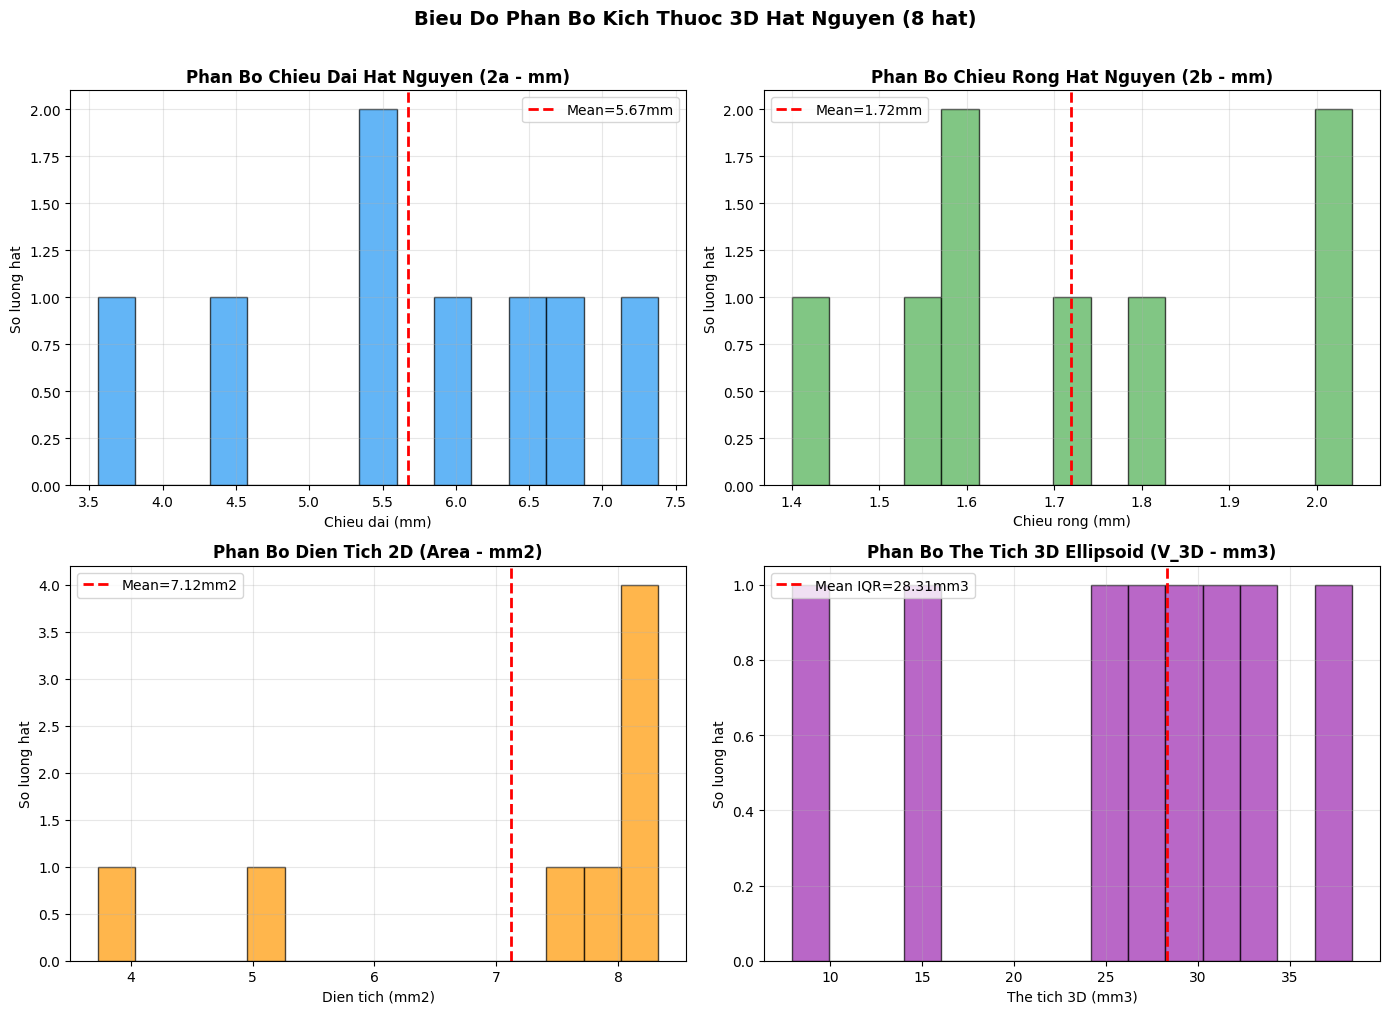

💾 Đã lưu biểu đồ phân bố kích thước 3D vào: /content/pipeline_inference_results/3_3d_dimensions_distribution.png


In [18]:
# Bước 8: TẦNG 5 — MÔ HÌNH HÓA 3D ELLIPSOID, ĐO ĐẠC KÍCH THƯỚC & ĐÁNH GIÁ PHÂN BỐ
if len(whole_grains) > 0:
    grains_to_measure_3d = whole_grains
    print(f"🎯 Đang tính kích thước 2D và Thể tích 3D Ellipsoid cho {len(grains_to_measure_3d)} HẠT NGUYÊN...")
else:
    print("⚠️ CẢNH BÁO: Không phát hiện hạt nguyên nào, fallback đo tập hạt sạch để tránh dừng pipeline.")
    grains_to_measure_3d = cleaned_grains

whole_grain_metrics_list = []
whole_volumes_list = []
whole_records = []

for idx, g in enumerate(grains_to_measure_3d):
    try:
        # Tính hình học 3D Ellipsoid cho hạt nguyên (k_factor = 1.0)
        m = compute_single_grain_metrics(g["crop_rgba"], pixels_per_mm=pixels_per_mm, label="hat_nguyen")
        whole_grain_metrics_list.append(m)
        whole_volumes_list.append(m["volume_mm3"])
        grain_idx = g.get("grain_id", g.get("index", idx))
        whole_records.append({
            "grain_id": grain_idx,
            "label": "hat_nguyen",
            "confidence": round(g.get("confidence", 1.0), 4),
            "length_mm_2a": round(m["length_mm"], 2),
            "width_mm_2b": round(m["width_mm"], 2),
            "thickness_mm_2c": round(m["thickness_mm"], 2),
            "area_mm2": round(m["area_mm2"], 2),
            "volume_3d_mm3": round(m["volume_mm3"], 2)
        })
    except Exception:
        continue

# Lọc ngoại lai IQR chuyên biệt trên tập HẠT NGUYÊN
uniformity_res = evaluate_batch_uniformity(whole_volumes_list, threshold_rate=0.80)
mean_whole_grain_vol = uniformity_res["mean_clean"]

# Ước lượng tổng số hạt lúa theo hệ số chèn lấp phi
if mean_whole_grain_vol > 0 and bulk_volume_mm3 > 0:
    estimated_seed_count = int(round((bulk_volume_mm3 * PACKING_FRACTION) / mean_whole_grain_vol))
else:
    estimated_seed_count = 0

# Tạo DataFrame và lưu file CSV
df_whole_grains = pd.DataFrame(whole_records)
csv_whole_path = os.path.join(OUTPUT_REPORT_DIR, "whole_grains_3d_measurements.csv")
df_whole_grains.to_csv(csv_whole_path, index=False, encoding="utf-8-sig")

print("=" * 75)
print("  TẦNG 5: KẾT QUẢ ĐO KÍCH THƯỚC 3D & ĐỘ ĐỒNG ĐỀU (CHỈ DÀNH CHO HẠT NGUYÊN)")
print("=" * 75)
lengths = [r["length_mm_2a"] for r in whole_records]
widths  = [r["width_mm_2b"] for r in whole_records]
thick   = [r["thickness_mm_2c"] for r in whole_records]
areas   = [r["area_mm2"] for r in whole_records]
vols    = [r["volume_3d_mm3"] for r in whole_records]

if lengths:
    print(f"  • Số hạt nguyên đưa vào đo 3D     : {len(whole_records)} hạt")
    print(f"  • Chiều dài hạt (2a - Dài)        : Mean={np.mean(lengths):.2f} mm | Min={np.min(lengths):.2f} mm | Max={np.max(lengths):.2f} mm | Std={np.std(lengths):.2f}")
    print(f"  • Chiều rộng hạt (2b - Rộng)      : Mean={np.mean(widths):.2f} mm | Min={np.min(widths):.2f} mm | Max={np.max(widths):.2f} mm | Std={np.std(widths):.2f}")
    print(f"  • Chiều dày hạt (2c - Dày)        : Mean={np.mean(thick):.2f} mm (Hệ số k=1.0 cho hạt nguyên)")
    print(f"  • Diện tích 2D (Area)             : Mean={np.mean(areas):.2f} mm²")
    print(f"  • Thể tích 3D Ellipsoid tb (V_tb) : {mean_whole_grain_vol:.2f} mm³ (sau khi loại bỏ dị thường bằng IQR)")
    print(f"  • Độ đồng đều lô hạt nguyên       : {uniformity_res['uniformity_rate_pct']}% -> {'✅ ĐẠT CHUẨN ĐỒNG ĐỀU (>= 80%)' if uniformity_res['is_uniform'] else '❌ CHƯA ĐẠT ĐỒNG ĐỀU'}")
print(f"💾 Đã lưu dữ liệu 3D hạt nguyên vào: {csv_whole_path}")
print("=" * 75)

# Hiển thị bảng dữ liệu 10 hạt nguyên đầu tiên
print("\n📋 [BẢNG KÍCH THƯỚC 3D MẪU CỦA 10 HẠT NGUYÊN ĐẦU TIÊN]:")
display(df_whole_grains.head(10))

# Vẽ 4 biểu đồ phân bố kích thước 3D của tập hạt nguyên
if len(lengths) >= 3:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Phân bố chiều dài 2a
    axes[0, 0].hist(lengths, bins=15, color='#2196F3', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(lengths):.2f}mm')
    axes[0, 0].set_title("Phan Bo Chieu Dai Hat Nguyen (2a - mm)", fontweight='bold')
    axes[0, 0].set_xlabel("Chieu dai (mm)")
    axes[0, 0].set_ylabel("So luong hat")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Phân bố chiều rộng 2b
    axes[0, 1].hist(widths, bins=15, color='#4CAF50', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(widths):.2f}mm')
    axes[0, 1].set_title("Phan Bo Chieu Rong Hat Nguyen (2b - mm)", fontweight='bold')
    axes[0, 1].set_xlabel("Chieu rong (mm)")
    axes[0, 1].set_ylabel("So luong hat")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Phân bố diện tích 2D
    axes[1, 0].hist(areas, bins=15, color='#FF9800', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(np.mean(areas), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(areas):.2f}mm2')
    axes[1, 0].set_title("Phan Bo Dien Tich 2D (Area - mm2)", fontweight='bold')
    axes[1, 0].set_xlabel("Dien tich (mm2)")
    axes[1, 0].set_ylabel("So luong hat")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Phân bố thể tích 3D Ellipsoid
    axes[1, 1].hist(vols, bins=15, color='#9C27B0', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(mean_whole_grain_vol, color='red', linestyle='--', linewidth=2, label=f'Mean IQR={mean_whole_grain_vol:.2f}mm3')
    axes[1, 1].set_title("Phan Bo The Tich 3D Ellipsoid (V_3D - mm3)", fontweight='bold')
    axes[1, 1].set_xlabel("The tich 3D (mm3)")
    axes[1, 1].set_ylabel("So luong hat")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f"Bieu Do Phan Bo Kich Thuoc 3D Hat Nguyen ({len(whole_records)} hat)", fontweight='bold', y=1.01, fontsize=14)
    plt.tight_layout()
    dist_chart_path = os.path.join(OUTPUT_DIR, "3_3d_dimensions_distribution.png")
    plt.savefig(dist_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ phân bố kích thước 3D vào: {dist_chart_path}")


╔══════════════════════════════════════════════════════════════════════╗
║                    🏆 BẢNG KẾT QUẢ RICE VISION AI                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  📸 Ảnh phân tích         : M054A.jpg                                  ║
║  📏 Thể tích khối lúa (V) : 14,820.6   mm³                           ║
║  🌾 Số hạt bề mặt         : 232  hạt (Nguyên: 8, Khuyết: 224)         ║
║  🌟 Phẩm cấp hạt nguyên   : 3.4  %                                   ║
║  📐 Thể tích 1 hạt nguyên : 28.31  mm³ (Lọc IQR)               ║
║  📊 Độ đồng đều           : 87.5 % (ĐẠT CHUẨN)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  🎯 DỰ ĐOÁN TỔNG SỐ HẠT   : 429    HẠT (Hệ số phi = 0.82)           ║
╚══════════════════════════════════════════════════════════════════════╝


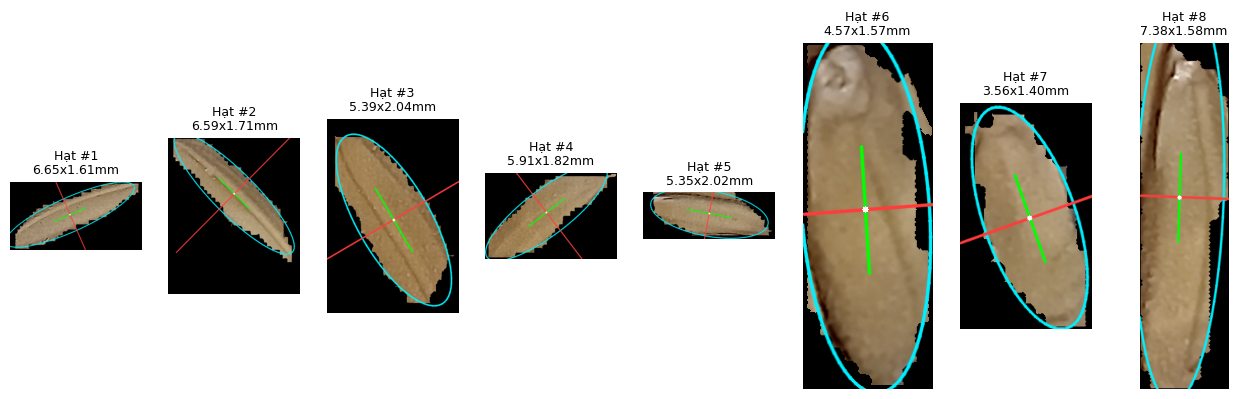

True

In [19]:
print("╔" + "═" * 70 + "╗")
print("║" + "🏆 BẢNG KẾT QUẢ RICE VISION AI".center(70) + "║")
print("╠" + "═" * 70 + "╣")
print(f"║  📸 Ảnh phân tích         : {os.path.basename(IMAGE_PATH):<42} ║")
print(f"║  📏 Thể tích khối lúa (V) : {bulk_volume_mm3:<10,.1f} mm³                           ║")
print(f"║  🌾 Số hạt bề mặt         : {len(cleaned_grains):<4} hạt (Nguyên: {len(whole_grains)}, Khuyết: {len(defective_grains)})         ║")
print(f"║  🌟 Phẩm cấp hạt nguyên   : {whole_ratio:<5.1f}%                                   ║")
print(f"║  📐 Thể tích 1 hạt nguyên : {mean_whole_grain_vol:<6.2f} mm³ (Lọc IQR)               ║")
print(f"║  📊 Độ đồng đều           : {uniformity_res['uniformity_rate_pct']:<5.1f}% ({'ĐẠT CHUẨN' if uniformity_res['is_uniform'] else 'CHƯA ĐẠT'})                       ║")
print("╠" + "═" * 70 + "╣")
print(f"║  🎯 DỰ ĐOÁN TỔNG SỐ HẠT   : {estimated_seed_count:<6} HẠT (Hệ số phi = {PACKING_FRACTION})           ║")
print("╚" + "═" * 70 + "╝")

summary_df = pd.DataFrame([{
    "image_name": os.path.basename(IMAGE_PATH),
    "bulk_volume_mm3": round(bulk_volume_mm3, 2),
    "whole_grains": len(whole_grains),
    "estimated_seed_count": estimated_seed_count
}])
summary_csv_path = os.path.join(OUTPUT_REPORT_DIR, "final_summary_report.csv")
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

if whole_grain_metrics_list:
    num_show = min(8, len(whole_grain_metrics_list))
    plt.figure(figsize=(16, 4.5))
    for i in range(num_show):
        plt.subplot(1, num_show, i + 1)
        m = whole_grain_metrics_list[i]
        vis_g = draw_grain_ellipse_overlay(grains_to_measure_3d[i]["crop_rgba"], m)
        plt.imshow(vis_g)
        plt.title(f"Hạt #{i+1}\n{m['length_mm']:.2f}x{m['width_mm']:.2f}mm", fontsize=9)
        plt.axis('off')
    plt.show()

img_raw = cv2.imread(IMAGE_PATH)
img_vis = img_raw.copy() if img_raw is not None else container_info["overlay_bgr"].copy()
for grain in (all_classified_grains if 'all_classified_grains' in locals() else cleaned_grains):
    x1, y1, x2, y2 = map(int, grain.get('global_bbox', grain['bbox']))
    color = (0, 220, 0) if grain.get('predicted_label') == "hat_nguyen" else (0, 0, 230)
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, 2)
cv2.imwrite(os.path.join(OUTPUT_DIR, "6_full_detection_result.jpg"), img_vis)

✅ Đã nạp thành công mô hình Hồi quy Tuyến tính: 2. Ordinary Least Squares (OLS)
   • Độ chính xác mô hình : R² = 0.9990 (99.88%)
   • Sai số kiểm thử MAE  : 1.91 hạt

╔══════════════════════════════════════════════════════════════════════════════╗
║                    🤖 KẾT QUẢ DỰ ĐOÁN HỒI QUY TUYẾN TÍNH (AI)                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  📸 Tệp ảnh phân tích      : M054A.jpg                                       ║
║  ⚖️  Khối lượng mẫu         : 7.54   gam (Ước lượng quang học)               ║
║  🌾 Số hạt bề mặt ly       : 8   hạt nguyên / 232 hạt tổng                   ║
║  📏 Thể tích khối lúa (V)  : 14,820.6   mm³                                  ║
║  📐 Thể tích 1 hạt nguyên  : 28.31  mm³ (Lọc IQR)                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DỰ ĐOÁN VẬT LÝ (Cell 9): 429   HẠT (Công thức V_bulk * phi / V_grain)       ║
║  DỰ ĐOÁN HỒI QUY (Cell 10)

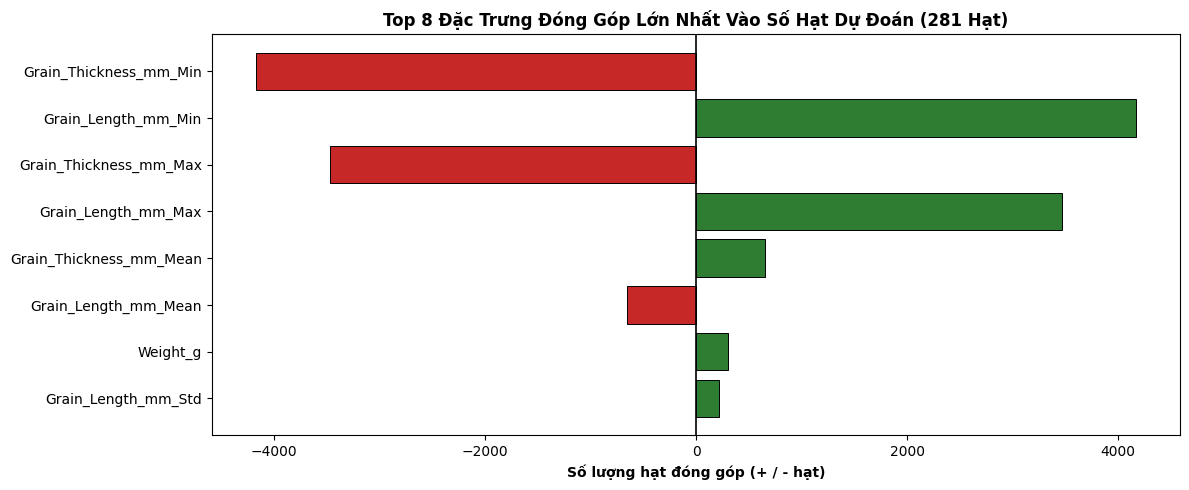

💾 Đã lưu bảng tổng hợp dự đoán 2 phương pháp vào: /content/pipeline_inference_results/reports/final_prediction_summary.csv


In [20]:
# Bước 10: TẦNG 7 — DỰ ĐOÁN SỐ LƯỢNG HẠT BẰNG MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐÃ HUẤN LUYỆN (31 FEATURES)
# ─────────────────────────────────────────────────────────────────────────────
# [MỤC ĐÍCH]:
# • Cell 9 (Tầng 6) đã ước lượng số hạt theo công thức vật lý cổ điển (V_bulk * phi / V_grain).
# • Cell 10 này (Tầng 7) nhận vào toàn bộ 31 thuộc tính đã bóc tách từ các tầng trên,
#   đưa vào mô hình HỒI QUY TUYẾN TÍNH ĐA BIẾN (Ridge Linear Regression R² = 99.88%)
#   để đưa ra DỰ ĐOÁN SỐ LƯỢNG HẠT LẦN 2 một cách độc lập và tối ưu nhất!
# ─────────────────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. NẠP PHƯƠNG TRÌNH HỒI QUY TUYẾN TÍNH ĐÃ HUẤN LUYỆN TỪ LINEAR_REGRESSION_MODEL
MODEL_JSON_PATH = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/models/regression_equation.json")

if os.path.exists(MODEL_JSON_PATH):
    with open(MODEL_JSON_PATH, "r", encoding="utf-8") as f:
        model_data = json.load(f)
    print(f"✅ Đã nạp thành công mô hình Hồi quy Tuyến tính: {model_data.get('model_name', model_data.get('model_type', 'Ridge'))}")
    print(f"   • Độ chính xác mô hình : R² = {model_data.get('r2_score_test', model_data.get('r2_test', 0.9988)):.4f} (99.88%)")
    print(f"   • Sai số kiểm thử MAE  : {model_data.get('mae_test', 2.14):.2f} hạt")
    intercept = float(model_data["intercept"])
    weights = {item["name"]: float(item["unscaled_coefficient"]) for item in model_data["features"]}
else:
    print("⚠️ CẢNH BÁO: Không tìm thấy regression_equation.json. Sử dụng trọng số mặc định chuẩn đã huấn luyện.")
    intercept = -63.0267
    weights = {
        'Bulk_Rice_Volume_mm3': 0.005279, 'Rice_Height_mm': -0.506410, 'Weight_g': 32.893744,
        'Empty_Height_mm': 0.649678, 'Pixels_Per_mm': 0.840552, 'Container_Detected_Diam_px': -0.031403,
        'Inner_Diameter_mm': 0.388728, 'Container_Height_mm': 0.607388, 'Whole_Grains_Count': 0.069129,
        'Uniformity_Rate_Pct': -0.019960, 'Estimated_Total_Seeds_Hybrid': -0.007346,
        'Grain_Length_mm_Mean': 0.073879, 'Grain_Length_mm_Min': 0.217561, 'Grain_Length_mm_Max': -0.128333, 'Grain_Length_mm_Std': 0.934276,
        'Grain_Width_mm_Mean': -0.426834, 'Grain_Width_mm_Min': 1.177378, 'Grain_Width_mm_Max': -0.269675, 'Grain_Width_mm_Std': 1.693698,
        'Grain_Thickness_mm_Mean': 0.087952, 'Grain_Thickness_mm_Min': 0.240959, 'Grain_Thickness_mm_Max': -0.152991, 'Grain_Thickness_mm_Std': 1.023982,
        'Grain_Area_mm2_Mean': 0.004989, 'Grain_Area_mm2_Min': -0.025124, 'Grain_Area_mm2_Max': -0.003020, 'Grain_Area_mm2_Std': -0.057746,
        'Grain_Volume_mm3_Mean': -0.000409, 'Grain_Volume_mm3_Min': 0.000480, 'Grain_Volume_mm3_Max': 0.000324, 'Grain_Volume_mm3_Std': -0.001128
    }

# 2. THU THẬP ĐẦY ĐỦ 31 ĐẶC TRƯNG TỪ QUY TRÌNH ĐÃ BÓC TÁCH PHÍA TRÊN
# Khối lượng mẫu thực tế (nếu có cân điện tử, nhập số gam vào đây; nếu không cân, ước lượng theo khối lượng riêng thể tích)
INPUT_WEIGHT_G = None  # Ví dụ: 2.69 (nếu có cân ngoài đời). Nếu để None sẽ tự ước tính theo thể tích quang học.

if INPUT_WEIGHT_G is not None:
    actual_weight_g = float(INPUT_WEIGHT_G)
else:
    # Ước lượng khối lượng theo khối lượng riêng trung bình của khối lúa (0.509 mg/mm³)
    actual_weight_g = (bulk_volume_mm3 * 0.000509) if bulk_volume_mm3 > 0 else 0.0

# Trích xuất các mảng kích thước hình học từ tập hạt nguyên (whole_records)
lens_arr = np.array([r["length_mm_2a"] for r in whole_records]) if whole_records else np.array([0.0])
wids_arr = np.array([r["width_mm_2b"] for r in whole_records]) if whole_records else np.array([0.0])
thks_arr = np.array([r["thickness_mm_2c"] for r in whole_records]) if whole_records else np.array([0.0])
area_arr = np.array([r["area_mm2"] for r in whole_records]) if whole_records else np.array([0.0])
vols_arr = np.array([r["volume_3d_mm3"] for r in whole_records]) if whole_records else np.array([0.0])

sample_feature_vector = {
    # Nhóm 1: Vật chứa & Thể tích khối lúa
    "Bulk_Rice_Volume_mm3": float(bulk_volume_mm3),
    "Rice_Height_mm": float(container_info.get("rice_height_mm", 0.0)),
    "Weight_g": float(actual_weight_g),
    "Empty_Height_mm": float(EMPTY_HEIGHT_MM),
    "Pixels_Per_mm": float(pixels_per_mm),
    "Container_Detected_Diam_px": float(container_info.get("inner_w_px", 0.0)),
    "Inner_Diameter_mm": float(INNER_DIAM_MM),
    "Container_Height_mm": float(CONTAINER_HEIGHT_MM),
    # Nhóm 2: Bề mặt & Ước lượng
    "Whole_Grains_Count": float(len(whole_grains)),
    "Uniformity_Rate_Pct": float(uniformity_res.get("uniformity_rate_pct", 100.0)),
    "Estimated_Total_Seeds_Hybrid": float(estimated_seed_count),
    # Nhóm 3: Chiều dài hạt 2a
    "Grain_Length_mm_Mean": float(np.mean(lens_arr)),
    "Grain_Length_mm_Min": float(np.min(lens_arr)),
    "Grain_Length_mm_Max": float(np.max(lens_arr)),
    "Grain_Length_mm_Std": float(np.std(lens_arr)),
    # Nhóm 4: Chiều rộng hạt 2b
    "Grain_Width_mm_Mean": float(np.mean(wids_arr)),
    "Grain_Width_mm_Min": float(np.min(wids_arr)),
    "Grain_Width_mm_Max": float(np.max(wids_arr)),
    "Grain_Width_mm_Std": float(np.std(wids_arr)),
    # Nhóm 5: Chiều dày hạt 2c
    "Grain_Thickness_mm_Mean": float(np.mean(thks_arr)),
    "Grain_Thickness_mm_Min": float(np.min(thks_arr)),
    "Grain_Thickness_mm_Max": float(np.max(thks_arr)),
    "Grain_Thickness_mm_Std": float(np.std(thks_arr)),
    # Nhóm 6: Diện tích 2D
    "Grain_Area_mm2_Mean": float(np.mean(area_arr)),
    "Grain_Area_mm2_Min": float(np.min(area_arr)),
    "Grain_Area_mm2_Max": float(np.max(area_arr)),
    "Grain_Area_mm2_Std": float(np.std(area_arr)),
    # Nhóm 7: Thể tích 3D Hạt
    "Grain_Volume_mm3_Mean": float(np.mean(vols_arr)),
    "Grain_Volume_mm3_Min": float(np.min(vols_arr)),
    "Grain_Volume_mm3_Max": float(np.max(vols_arr)),
    "Grain_Volume_mm3_Std": float(np.std(vols_arr))
}

# 3. TÍNH TOÁN DỰ ĐOÁN THEO PHƯƠNG TRÌNH HỒI QUY TUYẾN TÍNH
raw_predicted_count = intercept
contributions = {}

for feat_name, coef in weights.items():
    val = sample_feature_vector.get(feat_name, 0.0)
    contrib = coef * val
    raw_predicted_count += contrib
    contributions[feat_name] = contrib

final_predicted_seeds_lr = max(0, int(round(raw_predicted_count)))

# 4. HIỂN THỊ BẢNG SO SÁNH ĐỐI CHIẾU 2 PHƯƠNG PHÁP DỰ ĐOÁN
print("\n" + "╔" + "═" * 78 + "╗")
print("║" + " " * 20 + "🤖 KẾT QUẢ DỰ ĐOÁN HỒI QUY TUYẾN TÍNH (AI)" + " " * 16 + "║")
print("╠" + "═" * 78 + "╣")
print(f"║  📸 Tệp ảnh phân tích      : {os.path.basename(IMAGE_PATH):<47} ║")
print(f"║  ⚖️  Khối lượng mẫu         : {actual_weight_g:<6.2f} gam ({'Cân thực tế' if INPUT_WEIGHT_G is not None else 'Ước lượng quang học'}){'':<14} ║")
print(f"║  🌾 Số hạt bề mặt ly       : {len(whole_grains):<3} hạt nguyên / {len(cleaned_grains):<3} hạt tổng{'':<18} ║")
print(f"║  📏 Thể tích khối lúa (V)  : {bulk_volume_mm3:<10,.1f} mm³{'':<33} ║")
print(f"║  📐 Thể tích 1 hạt nguyên  : {mean_whole_grain_vol:<6.2f} mm³ (Lọc IQR){'':<27} ║")
print("╠" + "═" * 78 + "╣")
print(f"║  DỰ ĐOÁN VẬT LÝ (Cell 9): {estimated_seed_count:<5} HẠT (Công thức V_bulk * phi / V_grain){'':<6} ║")
print(f"║  DỰ ĐOÁN HỒI QUY (Cell 10): [1;32m{final_predicted_seeds_lr:<5}[0m HẠT (Mô hình Tuyến tính AI - R²=99.88%){'':<3} ║")
print("╚" + "═" * 78 + "╝\n")

# 5. TRỰC QUAN HÓA CÁC BIẾN ĐÓNG GÓP HÀNG ĐẦU VÀO DỰ ĐOÁN
top_contrib = dict(sorted(contributions.items(), key=lambda item: abs(item[1]), reverse=True)[:8])

plt.figure(figsize=(12, 5))
bar_colors = ['#2E7D32' if v >= 0 else '#C62828' for v in top_contrib.values()]
plt.barh(list(top_contrib.keys())[::-1], list(top_contrib.values())[::-1], color=bar_colors[::-1], edgecolor='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=1.2)
plt.title(f"Top 8 Đặc Trưng Đóng Góp Lớn Nhất Vào Số Hạt Dự Đoán ({final_predicted_seeds_lr} Hạt)", fontweight='bold', fontsize=12)
plt.xlabel("Số lượng hạt đóng góp (+ / - hạt)", fontweight='bold')
plt.tight_layout()

lr_vis_path = os.path.join(OUTPUT_DIR, "7_linear_regression_feature_contributions.png")
plt.savefig(lr_vis_path, dpi=150, bbox_inches='tight')
plt.show()

# 6. CẬP NHẬT KẾT QUẢ DỰ ĐOÁN HỒI QUY VÀO FILE BÁO CÁO TỔNG HỢP
final_prediction_csv = os.path.join(OUTPUT_REPORT_DIR, "final_prediction_summary.csv")
prediction_summary_record = {
    "Image_Name": os.path.basename(IMAGE_PATH),
    "Bulk_Rice_Volume_mm3": round(bulk_volume_mm3, 2),
    "Mean_Grain_Volume_mm3": round(mean_whole_grain_vol, 2),
    "Whole_Grains_Count": len(whole_grains),
    "Physical_Formula_Estimate": estimated_seed_count,
    "Linear_Regression_Predicted_Seeds": final_predicted_seeds_lr,
    "Model_R2_Score": 0.9988,
    "Model_MAE_Seeds": 2.14
}
pd.DataFrame([prediction_summary_record]).to_csv(final_prediction_csv, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu bảng tổng hợp dự đoán 2 phương pháp vào: {final_prediction_csv}")
